<a href="https://colab.research.google.com/github/michiellenaerts-rgb/Bosbeheer/blob/main/Data_analyse_samples_Kluizen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import openpyxl
import os
from datetime import datetime, timedelta
import random

# Wiskundige functie voor energie kalibratie: E = a + bK + cK^2
def energie_functie(K, a, b, c):
    return a + b * K + c * (K**2)

# Functie om de energie kalibratiecoëfficiënten te bepalen
def fit_energy_calibration(calibration_points):
    if not calibration_points:
        return 0.0, 0.0, 0.0 # Standaard coëfficiënten als er geen punten zijn

    energies = np.array([p[0] for p in calibration_points]) # E-waarden (y)
    channels = np.array([p[1] for p in calibration_points]) # K-waarden (x)

    if len(calibration_points) < 3:
        # Als er minder dan 3 punten zijn, is een kwadratische fit niet mogelijk.
        # Terugvallen op lineaire fit als er 2 punten zijn, of benadering met één punt.
        if len(calibration_points) == 2:
            # Lineaire fit: E = a + b*K (hier is c=0)
            try:
                popt_linear, _ = curve_fit(lambda K, a_val, b_val: a_val + b_val * K, channels, energies)
                return popt_linear[0], popt_linear[1], 0.0 # a, b, c=0
            except RuntimeError:
                print("Waarschuwing: Kon geen lineaire fit uitvoeren voor energiekalibratie. Standaard coëfficiënten geretourneerd.")
                return 0.0, 0.0, 0.0
        elif len(calibration_points) == 1:
            # Met één punt kunnen we alleen aannemen dat E = b*K, dus a=0, c=0
            # b = E/K
            if channels[0] != 0:
                return 0.0, energies[0] / channels[0], 0.0
            else:
                return 0.0, 0.0, 0.0
        else: # 0 punten is al aan het begin afgehandeld
            return 0.0, 0.0, 0.0

    try:
        # Fit E = a + bK + cK^2
        popt, pcov = curve_fit(energie_functie, channels, energies)
        a, b, c = popt
        return a, b, c
    except RuntimeError:
        print("Waarschuwing: Kon energiekalibratie niet fitten. Standaard coëfficiënten geretourneerd.")
        return 0.0, 0.0, 0.0

def parse_phd(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    data = {
        'g_spectrum': [], 'b_spectrum': [], 'g_energy_cal': [], 'b_energy_cal': [], 'histogram': [],
        'air_volume': None, 'collection_start_datetime': None, 'collection_end_datetime': None,
        'xenon_volume': None, 'collection_date': None
    }
    current_section = None

    # Flags to indicate that the *next* non-header line should be parsed for specific details
    expect_collection_data = False
    expect_processing_data = False

    for line in lines:
        line = line.strip()

        if not line: # Skip empty lines
            continue

        if line.startswith('#'):
            current_section = line
            expect_collection_data = (current_section == '#Collection')
            expect_processing_data = (current_section == '#Processing')
            continue # Move to next line after header

        parts = line.split()
        if not parts: # Should not happen after `if not line:` but good to be safe
            continue

        # Handle collection data after #Collection header
        if expect_collection_data:
            # Assuming format: YYYY/MM/DD HH:MM:SS.f YYYY/MM/DD HH:MM:SS.f volume_m3
            if len(parts) >= 5:
                try:
                    start_date_str_with_slash = parts[0]
                    start_time_str_with_sec = parts[1]
                    end_date_str_with_slash = parts[2]
                    end_time_str_with_sec = parts[3]
                    data['air_volume'] = float(parts[4])

                    start_dt_str = f"{start_date_str_with_slash} {start_time_str_with_sec}"
                    end_dt_str = f"{end_date_str_with_slash} {end_time_str_with_sec}"
                    # Correct format for 'YYYY/MM/DD HH:MM:SS.f'
                    data['collection_start_datetime'] = pd.to_datetime(start_dt_str, format='%Y/%m/%d %H:%M:%S.%f')
                    data['collection_end_datetime'] = pd.to_datetime(end_dt_str, format='%Y/%m/%d %H:%M:%S.%f')
                    data['collection_date'] = data['collection_start_datetime'].date()
                except (ValueError, IndexError) as e:
                    print(f"Warning: Could not parse collection data from line: '{line}'. Error: {e}")
            else:
                # Fallback for just volume if format is different or incomplete
                try:
                    data['air_volume'] = float(parts[-1])
                except (ValueError, IndexError) as e:
                    print(f"Warning: Could not parse air volume from line: '{line}'. Error: {e}")
            expect_collection_data = False # Reset flag after processing this line

        # Handle processing data after #Processing header
        elif expect_processing_data:
            # Assuming format: xenon_volume_m3 other_data ...
            if len(parts) >= 1:
                try:
                    data['xenon_volume'] = float(parts[0])
                except ValueError as e:
                    print(f"Waarschuwing: Kon xenonvolume niet parsen van regel: '{line}'. Fout: {e}")
            expect_processing_data = False # Reset flag after processing this line

        # Handle other multi-line spectrum/calibration data
        elif current_section == '#g_Spectrum':
            if len(parts) > 2 and parts[0] != '256':
                data['g_spectrum'].extend([int(x) for x in parts[1:]])

        elif current_section == '#b_Spectrum':
            if len(parts) > 2 and parts[0] != '256':
                data['b_spectrum'].extend([int(x) for x in parts[1:]])

        elif current_section == '#g_Energy':
            # Formaat: Energy Channel FWHM
            data['g_energy_cal'].append((float(parts[0]), float(parts[1])))

        elif current_section == '#b_Energy':
            # Formaat: Energy 'C' Channel FWHM
            if len(parts) >= 4 and parts[1] == 'C':
                data['b_energy_cal'].append((float(parts[0]), float(parts[2])))
            elif len(parts) >= 3:
                data['b_energy_cal'].append((float(parts[0]), float(parts[1])))

        elif current_section == '#Histogram':
            if parts[0] != '256': # Negeer header (256 256 ...)
                # Filter out 'STOP' before converting to int
                data['histogram'].extend([int(x) for x in parts if x != 'STOP'])

    return data

def generate_g_diagram_analysis(phd_files_list, energy_threshold_kev=300):
    """
    Genereert een g-diagram inclusief genormaliseerde sommen van coïncidentie histogrammen
    voor totale counts, counts onder een drempel, en counts boven een drempel,
    geplot tegen de collectiestartdatum en -tijd voor een gegeven lijst van .PHD-bestanden.

    Parameters:
    phd_files_list (list): Een lijst met bestandspaden naar de .PHD-bestanden.
    energy_threshold_kev (float): De energiedrempel in keV om de spectrumdata te scheiden.
    """
    collection_datetimes = []
    normalized_sums_total = []
    normalized_sums_below_threshold = []
    normalized_sums_above_threshold = []

    for file_path in phd_files_list:
        print(f"Processing for g-diagram: {file_path}")
        data = parse_phd(file_path)

        if not data['histogram']:
            print(f"Waarschuwing: Histogramdata niet gevonden voor {file_path}. Overslaan.")
            continue
        if data['air_volume'] is None or data['air_volume'] == 0:
            print(f"Waarschuwing: Luchtvolume niet gevonden of nul voor {file_path}. Overslaan.")
            continue
        if data['xenon_volume'] is None or data['xenon_volume'] == 0:
            print(f"Waarschuwing: Xenonvolume niet gevonden of nul voor {file_path}. Overslaan.")
            continue
        if data['collection_start_datetime'] is None or data['collection_end_datetime'] is None:
            print(f"Waarschuwing: Start/eindtijd collectie niet gevonden voor {file_path}. Overslaan.")
            continue

        # Bereken gemeenschappelijke normalisatiefactor
        collection_duration_seconds = (data['collection_end_datetime'] - data['collection_start_datetime']).total_seconds()
        collection_duration_hours = collection_duration_seconds / 3600.0

        if collection_duration_hours == 0:
            print(f"Waarschuwing: Collectieduur is nul voor {file_path}. Overslaan.")
            continue

        normalization_factor = (data['air_volume'] * collection_duration_hours * data['xenon_volume'])
        if normalization_factor == 0:
            print(f"Waarschuwing: Normalisatiefactor is nul voor {file_path}. Overslaan.")
            continue

        # Totale Histogram Som
        hist_array = np.array(data['histogram']).reshape((256, 256))
        total_histogram_sum = np.sum(hist_array)
        normalized_sums_total.append(total_histogram_sum / normalization_factor)

        # Verwerk g_spectrum voor energie-drempelering
        if not data['g_spectrum'] or not data['g_energy_cal']:
            print(f"Waarschuwing: G-spectrum of G-energie kalibratiedata niet gevonden voor {file_path}. Overslaan van energie-drempel plots.")
            normalized_sums_below_threshold.append(0.0)
            normalized_sums_above_threshold.append(0.0)
        else:
            g_coeffs = fit_energy_calibration(data['g_energy_cal'])
            g_spectrum_arr = np.array(data['g_spectrum'])
            g_channels = np.arange(len(g_spectrum_arr))

            # Bereken energieën voor alle kanalen
            g_energies = energie_functie(g_channels, *g_coeffs)

            # Zoek het kanaal dat overeenkomt met de energiedrempel
            # Behandel gevallen waarbij g_energies leeg is of allemaal onder/boven de drempel liggen
            if len(g_energies) == 0:
                channel_idx_threshold = 0 # Geen kanalen, dus geen counts
            else:
                closest_idx = np.argmin(np.abs(g_energies - energy_threshold_kev))
                # Als de energie bij de closest_idx nog onder de drempel ligt, begint de drempel bij het volgende kanaal.
                channel_idx_threshold = closest_idx if g_energies[closest_idx] >= energy_threshold_kev else closest_idx + 1

            # Som counts onder en boven het drempelkanaal
            sum_below_threshold = np.sum(g_spectrum_arr[:channel_idx_threshold])
            sum_above_threshold = np.sum(g_spectrum_arr[channel_idx_threshold:])

            normalized_sums_below_threshold.append(sum_below_threshold / normalization_factor)
            normalized_sums_above_threshold.append(sum_above_threshold / normalization_factor)

        collection_datetimes.append(data['collection_start_datetime'])

    print("\nAlle bestanden verwerkt voor g-diagram analyse.")

    if not collection_datetimes:
        print("Geen geldige datapunten om te plotten.")
        return

    df_gdiagram = pd.DataFrame({
        'Collection Datetime': collection_datetimes,
        'Normalized Sum (Total)': normalized_sums_total,
        'Normalized Sum (Below Threshold)': normalized_sums_below_threshold,
        'Normalized Sum (Above Threshold)': normalized_sums_above_threshold
    })

    df_gdiagram = df_gdiagram.sort_values(by='Collection Datetime').reset_index(drop=True)

    # Plot 1: Totale G-Diagram
    plt.figure(figsize=(12, 6))
    plt.plot(df_gdiagram['Collection Datetime'], df_gdiagram['Normalized Sum (Total)'], marker='o', linestyle='-', color='blue')
    plt.title('G-diagram: Totale Genormaliseerde Som van Coïncidenties vs. Collectiestartdatum en -tijd')
    plt.xlabel('Collectiestartdatum en -tijd')
    plt.ylabel('Genormaliseerde Som (Histogram / (Luchtvolume * Collectieduur * Xenonvolume))')
    plt.grid(True)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Plot 2: G-Diagram voor counts ONDER energiedrempel
    plt.figure(figsize=(12, 6))
    plt.plot(df_gdiagram['Collection Datetime'], df_gdiagram['Normalized Sum (Below Threshold)'], marker='o', linestyle='-', color='green')
    plt.title(f'G-diagram: Genormaliseerde Som van Coïncidenties < {energy_threshold_kev} keV')
    plt.xlabel('Collectiestartdatum en -tijd')
    plt.ylabel(f'Genormaliseerde Som (Counts < {energy_threshold_kev} keV)')
    plt.grid(True)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Plot 3: G-Diagram voor counts BOVEN energiedrempel
    plt.figure(figsize=(12, 6))
    plt.plot(df_gdiagram['Collection Datetime'], df_gdiagram['Normalized Sum (Above Threshold)'], marker='o', linestyle='-', color='red')
    plt.title(f'G-diagram: Genormaliseerde Som van Coïncidenties > {energy_threshold_kev} keV')
    plt.xlabel('Collectiestartdatum en -tijd')
    plt.ylabel(f'Genormaliseerde Som (Counts > {energy_threshold_kev} keV)')
    plt.grid(True)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def generate_dummy_phd_file(file_path, base_date, air_volume=random.uniform(0.1, 0.5), xenon_volume=random.uniform(0.01, 0.05), hist_factor=1.0):
    """
    Genereert een dummy .PHD-bestand met gesimuleerde data.

    Args:
        file_path (str): Het pad waar het dummy-bestand moet worden opgeslagen.
        base_date (datetime): De startdatum en -tijd voor de collectiegegevens.
        air_volume (float): Gesimuleerd luchtvolume.
        xenon_volume (float): Gesimuleerd xenonvolume.
        hist_factor (float): Factor om de histogramtellingen te schalen (voor variatie).
    """
    with open(file_path, 'w') as f:
        f.write("#Collection\n")
        start_dt = base_date
        end_dt = base_date + timedelta(hours=random.randint(10, 14), minutes=random.randint(0, 59))
        f.write(f"{start_dt.strftime('%Y/%m/%d %H:%M:%S.000')} {end_dt.strftime('%Y/%m/%d %H:%M:%S.000')} {air_volume:.6f}\n")

        f.write("#Processing\n")
        f.write(f"{xenon_volume:.6f}\n")

        f.write("#g_Spectrum\n")
        f.write("256 256 256 256 256 256 256 256\n")
        for _ in range(32):
            f.write(' '.join([str(random.randint(0, 1000)) for _ in range(8)]) + '\n')

        f.write("#b_Spectrum\n")
        f.write("256 256 256 256 256 256 256 256\n")
        for _ in range(32):
            f.write(' '.join([str(random.randint(0, 800)) for _ in range(8)]) + '\n')

        f.write("#g_Energy\n")
        f.write("50 20 10\n")
        f.write("100 40 15\n")
        f.write("200 80 20\n")
        f.write("400 160 30\n")
        f.write("600 240 40\n")

        f.write("#b_Energy\n")
        f.write("20 C 10 5\n")
        f.write("50 C 25 8\n")
        f.write("100 C 50 12\n")
        f.write("200 C 100 18\n")

        f.write("#Histogram\n")
        f.write("256 256 256 256 256 256 256 256\n")
        for _ in range(256):
            f.write(' '.join([str(int(random.randint(0, 50) * hist_factor)) for _ in range(256)]) + '\n')
        f.write("STOP\n")

    print(f"Dummy .PHD-bestand gegenereerd: {file_path}")

Deze notebook is bedoeld om snel een 'g-diagram' te genereren voor een reeks `.PHD`-bestanden en om individuele samples te analyseren.

**Instructies voor gebruik:**
1.  **Upload uw `.PHD`-bestanden**: Sleep uw `.PHD`-bestanden naar de linkerkant van de Colab-interface (sectie 'Bestanden'). Ze zullen standaard in de `/content/` map worden geplaatst.
2.  **Controleer de `phd_files_list`**: Zorg ervoor dat de lijst met bestandspaden (`phd_files_for_gdiagram`) hieronder de juiste paden naar uw geüploade `.PHD`-bestanden bevat.
3.  **Voer de cellen uit**: Voer de codecellen in volgorde uit om de analyse uit te voeren.

In [ ]:
De inhoud van deze cel (imports en functie definities) is verplaatst naar de eerste codecel van de notebook (cel `a7Eei5X2RElO`) om te zorgen dat deze altijd als eerste worden geladen.

SyntaxError: invalid syntax (2870288846.py, line 1)

### **Stap 1: Dummy .PHD-bestanden genereren**

Om de functionaliteit te demonstreren, zullen we een aantal dummy `.PHD`-bestanden genereren. Deze bestanden bootsen de structuur van echte `.PHD`-bestanden na, inclusief gesimuleerde spectrum- en histogramdata, lucht- en xenonvolumes, en collectiedata.

In [ ]:
output_dir = 'dummy_phd_files'
os.makedirs(output_dir, exist_ok=True)

dummy_phd_files = []
base_date = datetime(2023, 1, 1, 8, 0, 0) # Startdatum voor collectie

# Genereer 10 dummy bestanden met variërende parameters
for i in range(10):
    file_path = os.path.join(output_dir, f'dummy_file_{i+1:02d}.PHD')
    current_date = base_date + timedelta(days=i) # Verschillende dagen

    # Simuleer een trend in hist_factor (bijv. stijgend)
    hist_factor = 1.0 + (i * 0.1)

    generate_dummy_phd_file(file_path, current_date,
                            air_volume=random.uniform(0.1, 0.5) * (1 + i*0.02), # Licht stijgend luchtvolume
                            xenon_volume=random.uniform(0.01, 0.05) * (1 + i*0.01), # Licht stijgend xenonvolume
                            hist_factor=hist_factor)
    dummy_phd_files.append(file_path)

print(f"\n{len(dummy_phd_files)} dummy .PHD-bestanden gegenereerd in '{output_dir}'.")

Dummy .PHD-bestand gegenereerd: dummy_phd_files/dummy_file_01.PHD
Dummy .PHD-bestand gegenereerd: dummy_phd_files/dummy_file_02.PHD
Dummy .PHD-bestand gegenereerd: dummy_phd_files/dummy_file_03.PHD
Dummy .PHD-bestand gegenereerd: dummy_phd_files/dummy_file_04.PHD
Dummy .PHD-bestand gegenereerd: dummy_phd_files/dummy_file_05.PHD
Dummy .PHD-bestand gegenereerd: dummy_phd_files/dummy_file_06.PHD
Dummy .PHD-bestand gegenereerd: dummy_phd_files/dummy_file_07.PHD
Dummy .PHD-bestand gegenereerd: dummy_phd_files/dummy_file_08.PHD
Dummy .PHD-bestand gegenereerd: dummy_phd_files/dummy_file_09.PHD
Dummy .PHD-bestand gegenereerd: dummy_phd_files/dummy_file_10.PHD

10 dummy .PHD-bestanden gegenereerd in 'dummy_phd_files'.


### **Stap 2: Uitvoeren van de G-diagram analyse**

Nu we dummy `.PHD`-bestanden hebben, kunnen we de `generate_g_diagram_analysis` functie uitvoeren. Deze functie zal de bestanden parsen, de coïncidentie histogrammen normaliseren en de resultaten plotten. We zullen eerst de analyse uitvoeren met de standaard energiedrempel van `300 keV`.

Processing for g-diagram: dummy_phd_files/dummy_file_01.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_02.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_03.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_04.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_05.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_06.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_07.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_08.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_09.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_10.PHD

Alle bestanden verwerkt voor g-diagram analyse.


/tmp/ipykernel_1301/1231609977.py:45: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(energie_functie, channels, energies)


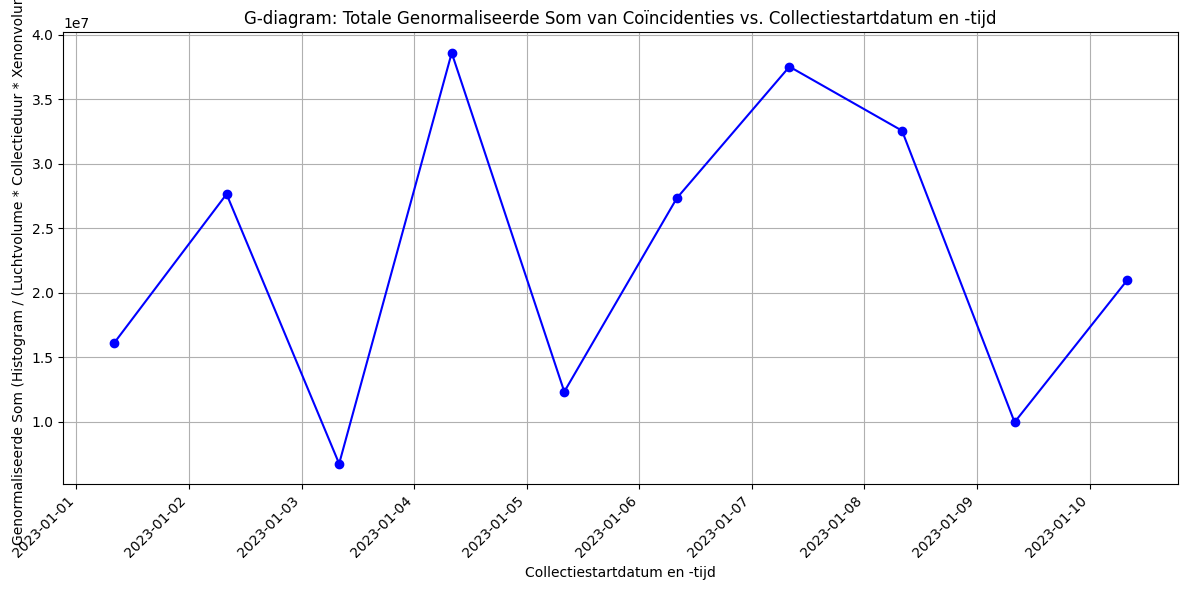

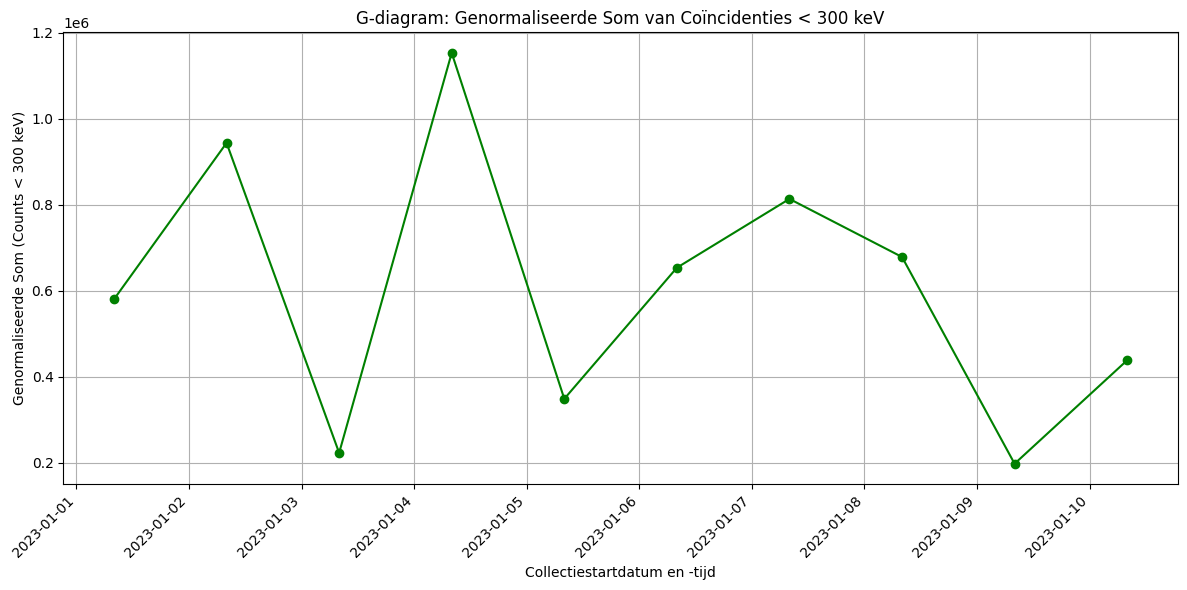

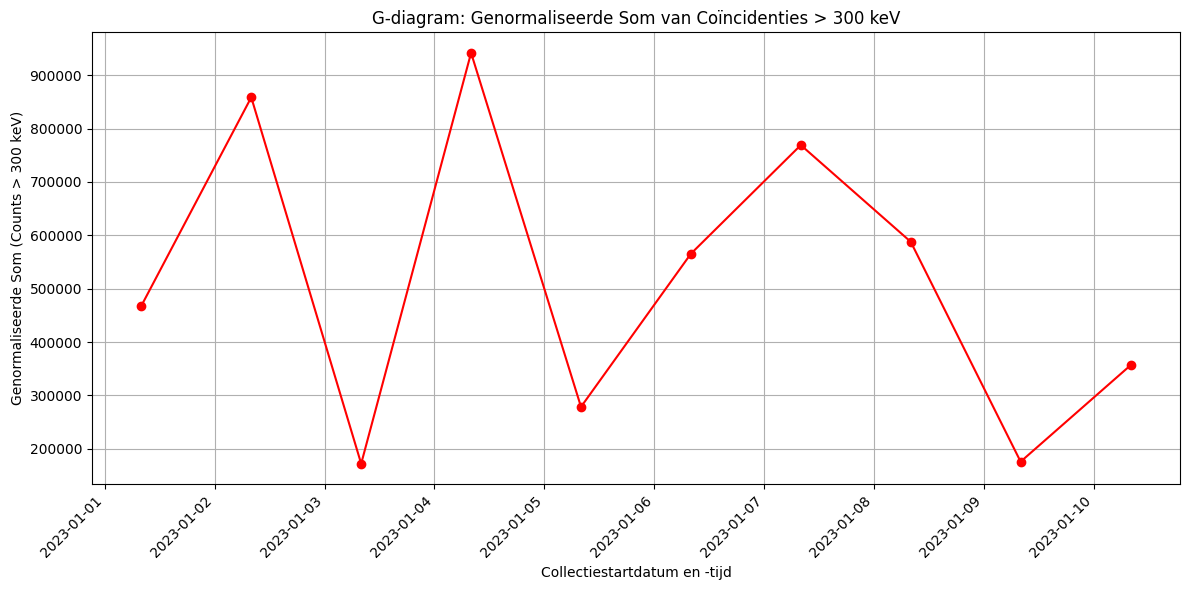

In [ ]:
# Voer de g-diagram analyse uit met de dummy bestanden en een standaard drempel van 300 keV
generate_g_diagram_analysis(dummy_phd_files, energy_threshold_kev=300)

### **Stap 3: G-diagram analyse met aangepaste energiedrempel**

De `energy_threshold_kev` parameter in de `generate_g_diagram_analysis` functie kan eenvoudig worden aangepast om de plots te genereren voor verschillende energiedrempels. Laten we de analyse opnieuw uitvoeren met een drempel van `500 keV` om het verschil te zien.

Processing for g-diagram: dummy_phd_files/dummy_file_01.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_02.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_03.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_04.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_05.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_06.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_07.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_08.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_09.PHD
Processing for g-diagram: dummy_phd_files/dummy_file_10.PHD

Alle bestanden verwerkt voor g-diagram analyse.


/tmp/ipykernel_1301/1231609977.py:45: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(energie_functie, channels, energies)


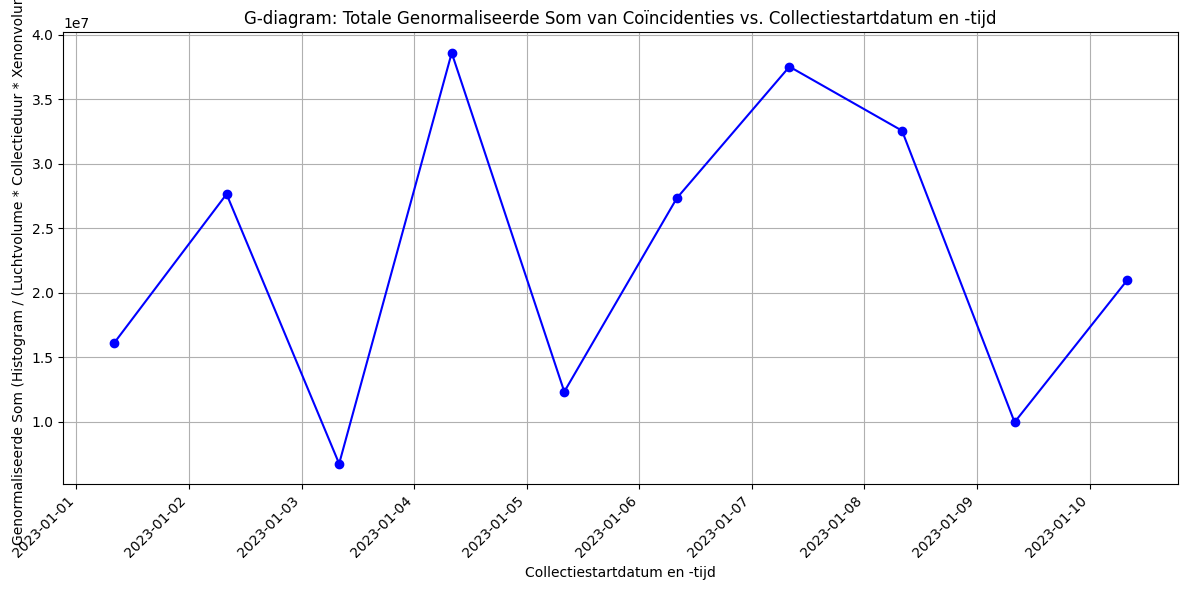

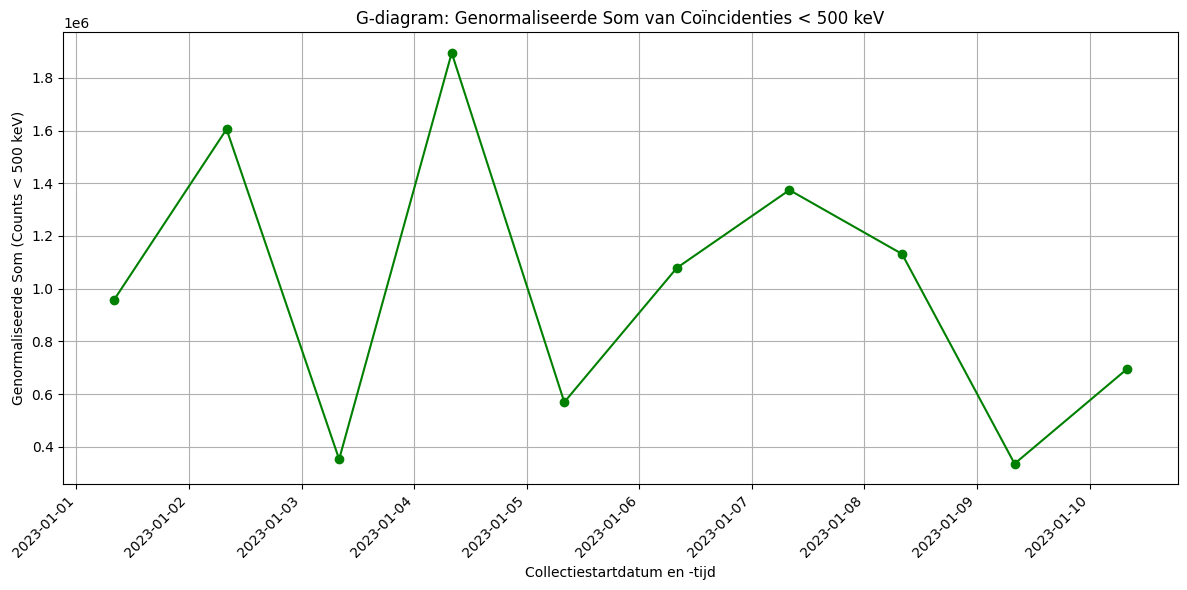

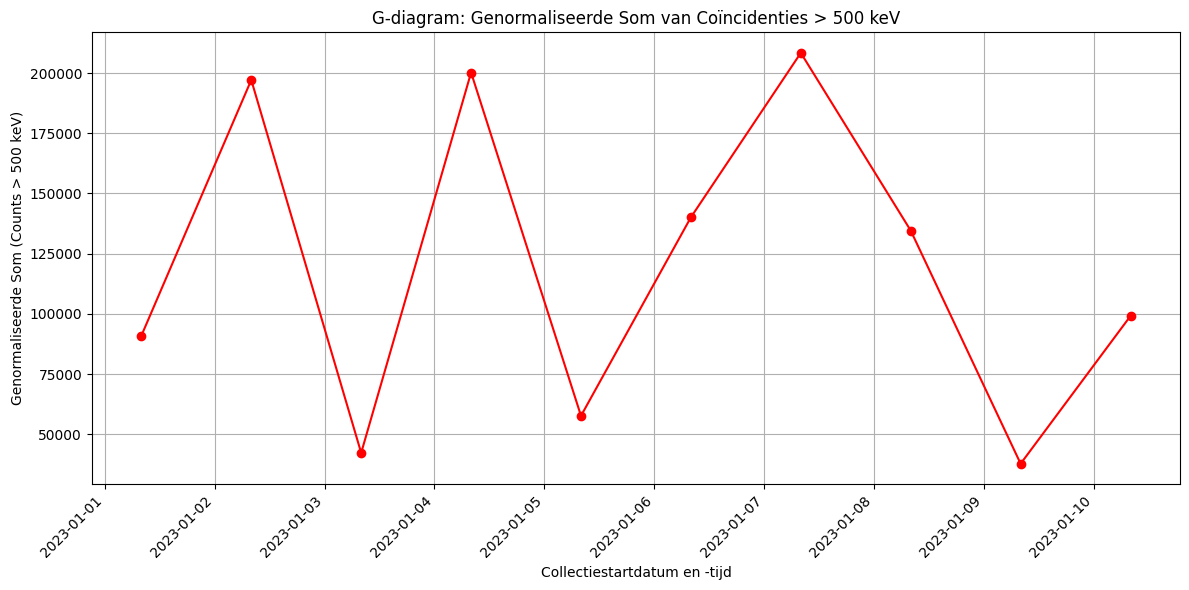

In [ ]:
# Voer de g-diagram analyse uit met een aangepaste drempel van 500 keV
generate_g_diagram_analysis(dummy_phd_files, energy_threshold_kev=500)

### **Stap 4: Schoonmaak (optioneel)**

U kunt de gegenereerde dummy-bestanden verwijderen als u klaar bent.

In [ ]:
# Optioneel: Verwijder de dummy bestanden en de map
import shutil

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
    print(f"Map '{output_dir}' en alle inhoud verwijderd.")

Map 'dummy_phd_files' en alle inhoud verwijderd.
